# 03a — The evaluation problem itself

**Phase 1.5, notebook 1 of 5.** Notebook-led, senior track.

## Why we're here

LUKI works: embeddings are computed, Qdrant returns ranked neighbors, the Gradio UI looks nice. But if a Senior ML interviewer opens with *"How do you know it works?"*, the honest answer right now is **"I don't."** That's the gap this phase closes.

This notebook doesn't compute any metric yet. It does something more important: it forces us to **stare at the problem** before we start optimizing a number. Three things by the end:

1. You can articulate **why retrieval eval is structurally different** from classification eval.
2. You can name the **three families of workaround** for the missing-labels problem, and **the bias of each on this dataset specifically**.
3. You understand that **picking an eval is a product decision in disguise** — not a statistics decision.

---

### Refresher — retrieval vs classification (30 seconds)

| | Classification | Retrieval |
|---|---|---|
| Output | One label | A **ranked list** |
| Ground truth | One correct answer per input | A **set** (possibly empty, possibly huge) of relevant docs |
| Success metric | Accuracy / F1 / AUC | Recall@k / mAP / NDCG / MRR |
| Label cost | O(N) — label every input | O(N × M) worst case — judge every (query, doc) pair |

The last row is why retrieval eval is hard: **you can't afford ground-truth labels**. Every eval strategy from here is a way to pretend you have labels when you don't.

### A word you'll hear a lot: *relevance judgment*

A relevance judgment is one atomic piece of supervision: *for query Q, is doc D relevant?* — a yes/no (or graded 0–3) answer. In academic IR (TREC, MSMARCO), teams of human annotators produce tens of thousands of these. We have **zero**. The rest of this notebook is about what we're allowed to do instead.

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Resolve repo root — notebooks live in ./notebooks/
REPO = Path().resolve().parent
sys.path.insert(0, str(REPO / "src"))

import pandas as pd
import numpy as np
from PIL import Image
from IPython.display import display, HTML

pd.set_option("display.max_colwidth", 80)
print("Repo:", REPO)

Repo: C:\winhome\dev\luki


In [2]:
# Load manifest (the photo library's metadata table)
manifest = pd.read_parquet(REPO / "data" / "processed" / "manifest.parquet")
RAW_DIR = REPO / "data" / "raw"

print(f"{len(manifest)} photos indexed")
print(f"Columns: {list(manifest.columns)}")
manifest.head(3)

205 photos indexed
Columns: ['medium', 'year', 'camera', 'session_name', 'roll_date', 'film_stock', 'film_iso', 'roll_tags', 'relative_path', 'filename', 'extension', 'size_bytes', 'file_hash', 'width', 'height', 'format', 'color_mode', 'datetime_original', 'camera_make', 'camera_model', 'focal_length_mm', 'aperture', 'iso', 'exposure_time', 'gps_lat', 'gps_lon']


,medium,year,camera,session_name,roll_date,film_stock,film_iso,roll_tags,relative_path,filename,...,color_mode,datetime_original,camera_make,camera_model,focal_length_mm,aperture,iso,exposure_time,gps_lat,gps_lon
0,digital,2026,canon-500d,20260201_chile-performers,NaN,NaN,<NA>,NaN,digital/2026/canon-500d/20260201_chile-performers/3L6A9776.jpg,3L6A9776.jpg,...,RGB,2026:02:01 12:13:52,Canon,Canon EOS 5D Mark III,16.0,6.3,1000.0,1/800,None,None
1,digital,2026,canon-500d,20260201_chile-performers,NaN,NaN,<NA>,NaN,digital/2026/canon-500d/20260201_chile-performers/3L6A9777.jpg,3L6A9777.jpg,...,RGB,2026:02:01 12:13:53,Canon,Canon EOS 5D Mark III,16.0,6.3,1000.0,1/800,None,None
2,digital,2026,canon-500d,20260201_chile-performers,NaN,NaN,<NA>,NaN,digital/2026/canon-500d/20260201_chile-performers/3L6A9779.jpg,3L6A9779.jpg,...,RGB,2026:02:01 12:14:11,Canon,Canon EOS 5D Mark III,16.0,6.3,1000.0,1/800,None,None


In [3]:
# Connect to Qdrant (must be running — `docker compose up qdrant api -d`)
from luki.api import services  # reuses the API's singletons

store = services.get_store()
print(f"Qdrant points: {store.count()}")
print("Vector dim: 1024  (DINOv3-ViT-L, L2-normalized)")

c:\winhome\dev\luki\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Qdrant points: 205
Vector dim: 1024  (DINOv3-ViT-L, L2-normalized)


c:\winhome\dev\luki\.venv\Lib\site-packages\qdrant_client\qdrant_remote.py:288: UserWarning: Failed to obtain server version. Unable to check client-server compatibility. Set check_compatibility=False to skip version check.
  show_warning(


## Knowing your data before designing the eval

**This step is non-skippable.** A senior never picks a metric without first looking at how the data is composed — because the eval design depends on what's actually there. Most eval bugs come from a label that *seems* informative but turns out to be missing or imbalanced in the real data.

Run the cell below. The structure that comes out determines everything else in this notebook.

In [4]:
# What are the candidate "relevance proxy" columns, and how usable is each?
candidate_proxies = ["medium", "camera", "year", "session_name", "roll_date", "roll_tags", "film_stock"]
rows = []
for col in candidate_proxies:
    rows.append({
        "column": col,
        "unique_values": manifest[col].nunique(dropna=True),
        "n_with_value": manifest[col].notna().sum(),
        "n_null":       manifest[col].isna().sum(),
    })
pd.DataFrame(rows)

,column,unique_values,n_with_value,n_null
0,medium,2,205,0
1,camera,2,205,0
2,year,2,205,0
3,session_name,1,19,186
4,roll_date,4,186,19
5,roll_tags,5,186,19
6,film_stock,3,109,96


In [5]:
# Group sizes for the two best candidates
print("--- roll_tags (the most usable grouping signal) ---")
print(manifest["roll_tags"].value_counts(dropna=False))
print()
print("--- medium x camera (the cohort split) ---")
print(manifest.groupby(["medium", "camera"]).size())

--- roll_tags (the most usable grouping signal) ---
roll_tags
vzla|2             40
sombrilla|playa    37
paloma|salsa       37
monserrat          36
vzla|1             36
NaN                19
Name: count, dtype: int64

--- medium x camera (the cohort split) ---
medium   camera        
digital  canon-500d         19
film     canon_prima_ii    186
dtype: int64


### What the data is actually telling us

Read off the cells above:

- **`session_name` is unusable**: only 1 unique value, 186 rows null. If we pick it, 90% of the library has no relevance label.
- **`roll_tags` is the workable proxy**: 5 groups of ~36–40 film photos. This is what we'll use as the metadata family.
- **The library splits cleanly into two cohorts**: 19 digital photos (Canon 500D, no roll information) and 186 film photos (Canon Prima II, distributed across 5 rolls).

That last point is the **real** difficulty axis for this dataset. It's not query-size — every roll has roughly the same number of photos. It's:

> **Does this query come from a cohort the metadata proxy can even *see*?**

For a film query: yes — `roll_tags` says "these 35 other photos are relevant."  
For a digital query: no — `roll_tags` is null, the proxy returns the empty set, the eval pretends the query has no relevant doc in the library.

**That coverage gap is itself the senior teaching moment.** A real-world dataset will almost always have cohorts your proxy doesn't cover. You either (a) build a different proxy for that cohort, (b) report metrics per-cohort and let the gap be visible, or (c) drop the cohort and document that you did. What you do *not* do is silently average over both cohorts and report one number — that number is a lie.

## Part 1 — Three real queries, eyeballed

Now I pick three queries deliberately along the cohort axis we just identified:

1. **FILM, roll A** — a film photo whose roll has rich `roll_tags` signal (~36 expected metadata-neighbors).
2. **FILM, roll B** — a film photo from a *different* roll (also ~36 expected neighbors, but different visual character).
3. **DIGITAL** — a digital photo with no roll information. The metadata proxy can't judge this one.

If you only ever look at queries from cohort 1+2, you'll over-estimate the system. The Digital query is the one a senior would *insist* on including in the demo, exactly because it's the case the proxy hides.

In [6]:
# Pick the three deliberate queries
film_rolls = manifest[manifest["roll_tags"].notna()]["roll_tags"].value_counts()
roll_a, roll_b = film_rolls.index[0], film_rolls.index[1]

def first_in(mask: pd.Series) -> pd.Series:
    return manifest[mask].iloc[0]

queries = {
    f"FILM,    roll='{roll_a}'":  first_in(manifest["roll_tags"] == roll_a),
    f"FILM,    roll='{roll_b}'":  first_in(manifest["roll_tags"] == roll_b),
    "DIGITAL, no roll metadata":  first_in(manifest["medium"] == "digital"),
}

for label, row in queries.items():
    print(f"{label:35s} → {row['filename']:50s}  camera={row['camera']:18s}  roll_tags={row['roll_tags']}")

FILM,    roll='vzla|2'              → 26_03_2026_0001-3.jpg                               camera=canon_prima_ii      roll_tags=vzla|2
FILM,    roll='sombrilla|playa'     → 04_10_2025_0001.jpg                                 camera=canon_prima_ii      roll_tags=sombrilla|playa
DIGITAL, no roll metadata           → 3L6A9776.jpg                                        camera=canon-500d          roll_tags=nan


In [15]:
# Helper: embed a library photo → query Qdrant → render query + top-k as HTML thumbnails.
from luki.embeddings.dataset import load_image, resolve_path

def _thumb_html(path: Path, label: str, px: int = 110, border: str = "#ddd") -> str:
    rel = path.resolve().as_uri().replace(RAW_DIR.resolve().as_uri(), "../data/raw")
    return (
        f'<div style="display:inline-block;margin:4px;text-align:center;font-size:10px;'
        f'max-width:{px}px">'
        f'<img src="{rel}" style="height:{px}px;border:2px solid {border}" />'
        f'<div>{label}</div></div>'
    )

def run_and_show(query_row: pd.Series, top_k: int = 10, title: str = "") -> list[dict]:
    q_path = resolve_path(query_row["relative_path"], RAW_DIR)
    img = load_image(q_path)
    embedder = services.get_embedder()
    vec = embedder.embed([img])[0]
    results = store.search(vec, top_k=top_k + 1)  # +1 to drop self-match

    query_hash = query_row["file_hash"]
    hits = [r for r in results if (r.payload or {}).get("file_hash") != query_hash][:top_k]

    html_parts = [f"<h4>{title}</h4>", _thumb_html(q_path, "QUERY", border="#c00")]
    html_parts.append("<span style='font-size:30px;color:#999'>&rarr;</span>")
    for i, h in enumerate(hits, 1):
        p = h.payload or {}
        hit_path = resolve_path(p["relative_path"], RAW_DIR)
        label = f"#{i}  s={h.score:.3f}"
        html_parts.append(_thumb_html(hit_path, label))
    display(HTML("".join(html_parts)))
    return [{"rank": i, "score": h.score, **(h.payload or {})} for i, h in enumerate(hits, 1)]

all_hits = {label: run_and_show(row, top_k=10, title=label) for label, row in queries.items()}

### Your turn — eyeball each row

For each of the three queries above:

- **How many of the 10 results look "relevant" to you?** (Whatever that word means to you right now.)
- **Did your definition of "relevant" stay constant across all three queries, or did it shift?** Why?
- **The DIGITAL query — were the top hits other digital photos, or did film photos dominate?** That single observation tells you something about the embedding space.

There are no wrong answers here. The point is: **before any metric exists, you should already have *qualitative* hypotheses about what the eval will reveal**. Then the metric either confirms or refutes the hypothesis. Skipping this step and going straight to numbers is how people end up reporting metrics they don't believe.

---

### Why naive "accuracy" is the wrong question

If someone asks *"what's the accuracy of LUKI?"*, there is literally no well-defined answer. Three independent reasons:

1. **Accuracy of what?** Per-query top-1? Per-query top-10? Per-(query, doc) pair averaged? Each is a different number. There's no canonical denominator.
2. **There's no single correct doc.** A query like *"beach sunset"* has *many* relevant docs in the library. Forcing one correct answer is a category error.
3. **Rank matters for users, but accuracy ignores it.** A relevant doc at rank 1 is worth far more than at rank 10. Accuracy treats them the same.

The IR field has spent 50 years inventing metrics specifically to fix these. We'll meet them in `03b`.

## Part 2 — The three workaround families

We have zero relevance judgments. Any eval we build is going to *fake* some. Three families of fake supervision, each with a different bias:

| Family | Where "relevance" comes from | Bias |
|---|---|---|
| **(A) Metadata proxy** | Same `roll_tags` (or `roll_date` / `camera`) | Temporal/cohort proximity ≠ visual similarity. **Empty for cohorts that lack the column** — that's the digital problem we're about to see. |
| **(B) Augmentation-synthetic** | The original photo, queried via an augmented copy | Measures invariance to *the augmentations you chose*. Circular for DINOv3 (trained on these). |
| **(C) Human judgment** | You (or Mechanical Turk) click yes/no | Small N, expensive, personal taste. Closest to the actual user experience. |

A senior's move: **use at least two of these and report results side-by-side**, because each one's bias is different, and agreement across biased estimators is a stronger signal than any single one. Same logic as ensemble eval, or triangulation in empirical science.

We'll now run all three families on the **DIGITAL query** specifically. The choice is intentional — it's the cohort where Family A is going to *fail visibly*, and that failure is the lesson.

In [16]:
# Pick the digital query (the one Family A can't judge) for the deep dive
demo_label = "DIGITAL, no roll metadata"
demo_row = queries[demo_label]
demo_hits = all_hits[demo_label]
demo_path = resolve_path(demo_row["relative_path"], RAW_DIR)
print(f"Demo query: {demo_row['filename']}")
print(f"  roll_tags: {demo_row['roll_tags']}    medium: {demo_row['medium']}    camera: {demo_row['camera']}")

Demo query: 3L6A9776.jpg
  roll_tags: nan    medium: digital    camera: canon-500d


In [17]:
# --- Family A: Metadata proxy ---
# What does "same roll_tags" call relevant?
demo_roll = demo_row["roll_tags"]
if pd.isna(demo_roll):
    n_a = 0
else:
    n_a = ((manifest["roll_tags"] == demo_roll) & (manifest["file_hash"] != demo_row["file_hash"])).sum()

print(f"(A) roll_tags = {demo_roll!r}")
print(f"    Family A says {n_a} docs are relevant.")
print()

if n_a == 0:
    print("    >>> Family A has NOTHING to say about this query. <<<")
    print("    This is the coverage gap. If you ran the eval naively over all 205 photos")
    print("    and reported a single mean Recall@k, the digital cohort would either")
    print("      (a) silently drop out of the average  → biased UP toward film performance")
    print("      (b) get counted as 0/0 = NaN          → averaging breaks")
    print("      (c) get counted as 0/k = 0.0          → biased DOWN, penalizing the system")
    print("                                              for a query the eval can't even judge.")
    print("    Each option is a different kind of lie. Naming this in an interview = senior signal.")

(A) roll_tags = nan
    Family A says 0 docs are relevant.

    >>> Family A has NOTHING to say about this query. <<<
    This is the coverage gap. If you ran the eval naively over all 205 photos
    and reported a single mean Recall@k, the digital cohort would either
      (a) silently drop out of the average  → biased UP toward film performance
      (b) get counted as 0/0 = NaN          → averaging breaks
      (c) get counted as 0/k = 0.0          → biased DOWN, penalizing the system
                                              for a query the eval can't even judge.
    Each option is a different kind of lie. Naming this in an interview = senior signal.


In [18]:
# Show Family A working as intended on the FILM query for contrast
for label in [k for k in queries if "FILM" in k]:
    row = queries[label]
    n = ((manifest["roll_tags"] == row["roll_tags"]) & (manifest["file_hash"] != row["file_hash"])).sum()
    print(f"(A) on {label:35s} → {n} relevant docs (roll_tags={row['roll_tags']!r})")

(A) on FILM,    roll='vzla|2'              → 39 relevant docs (roll_tags='vzla|2')
(A) on FILM,    roll='sombrilla|playa'     → 36 relevant docs (roll_tags='sombrilla|playa')



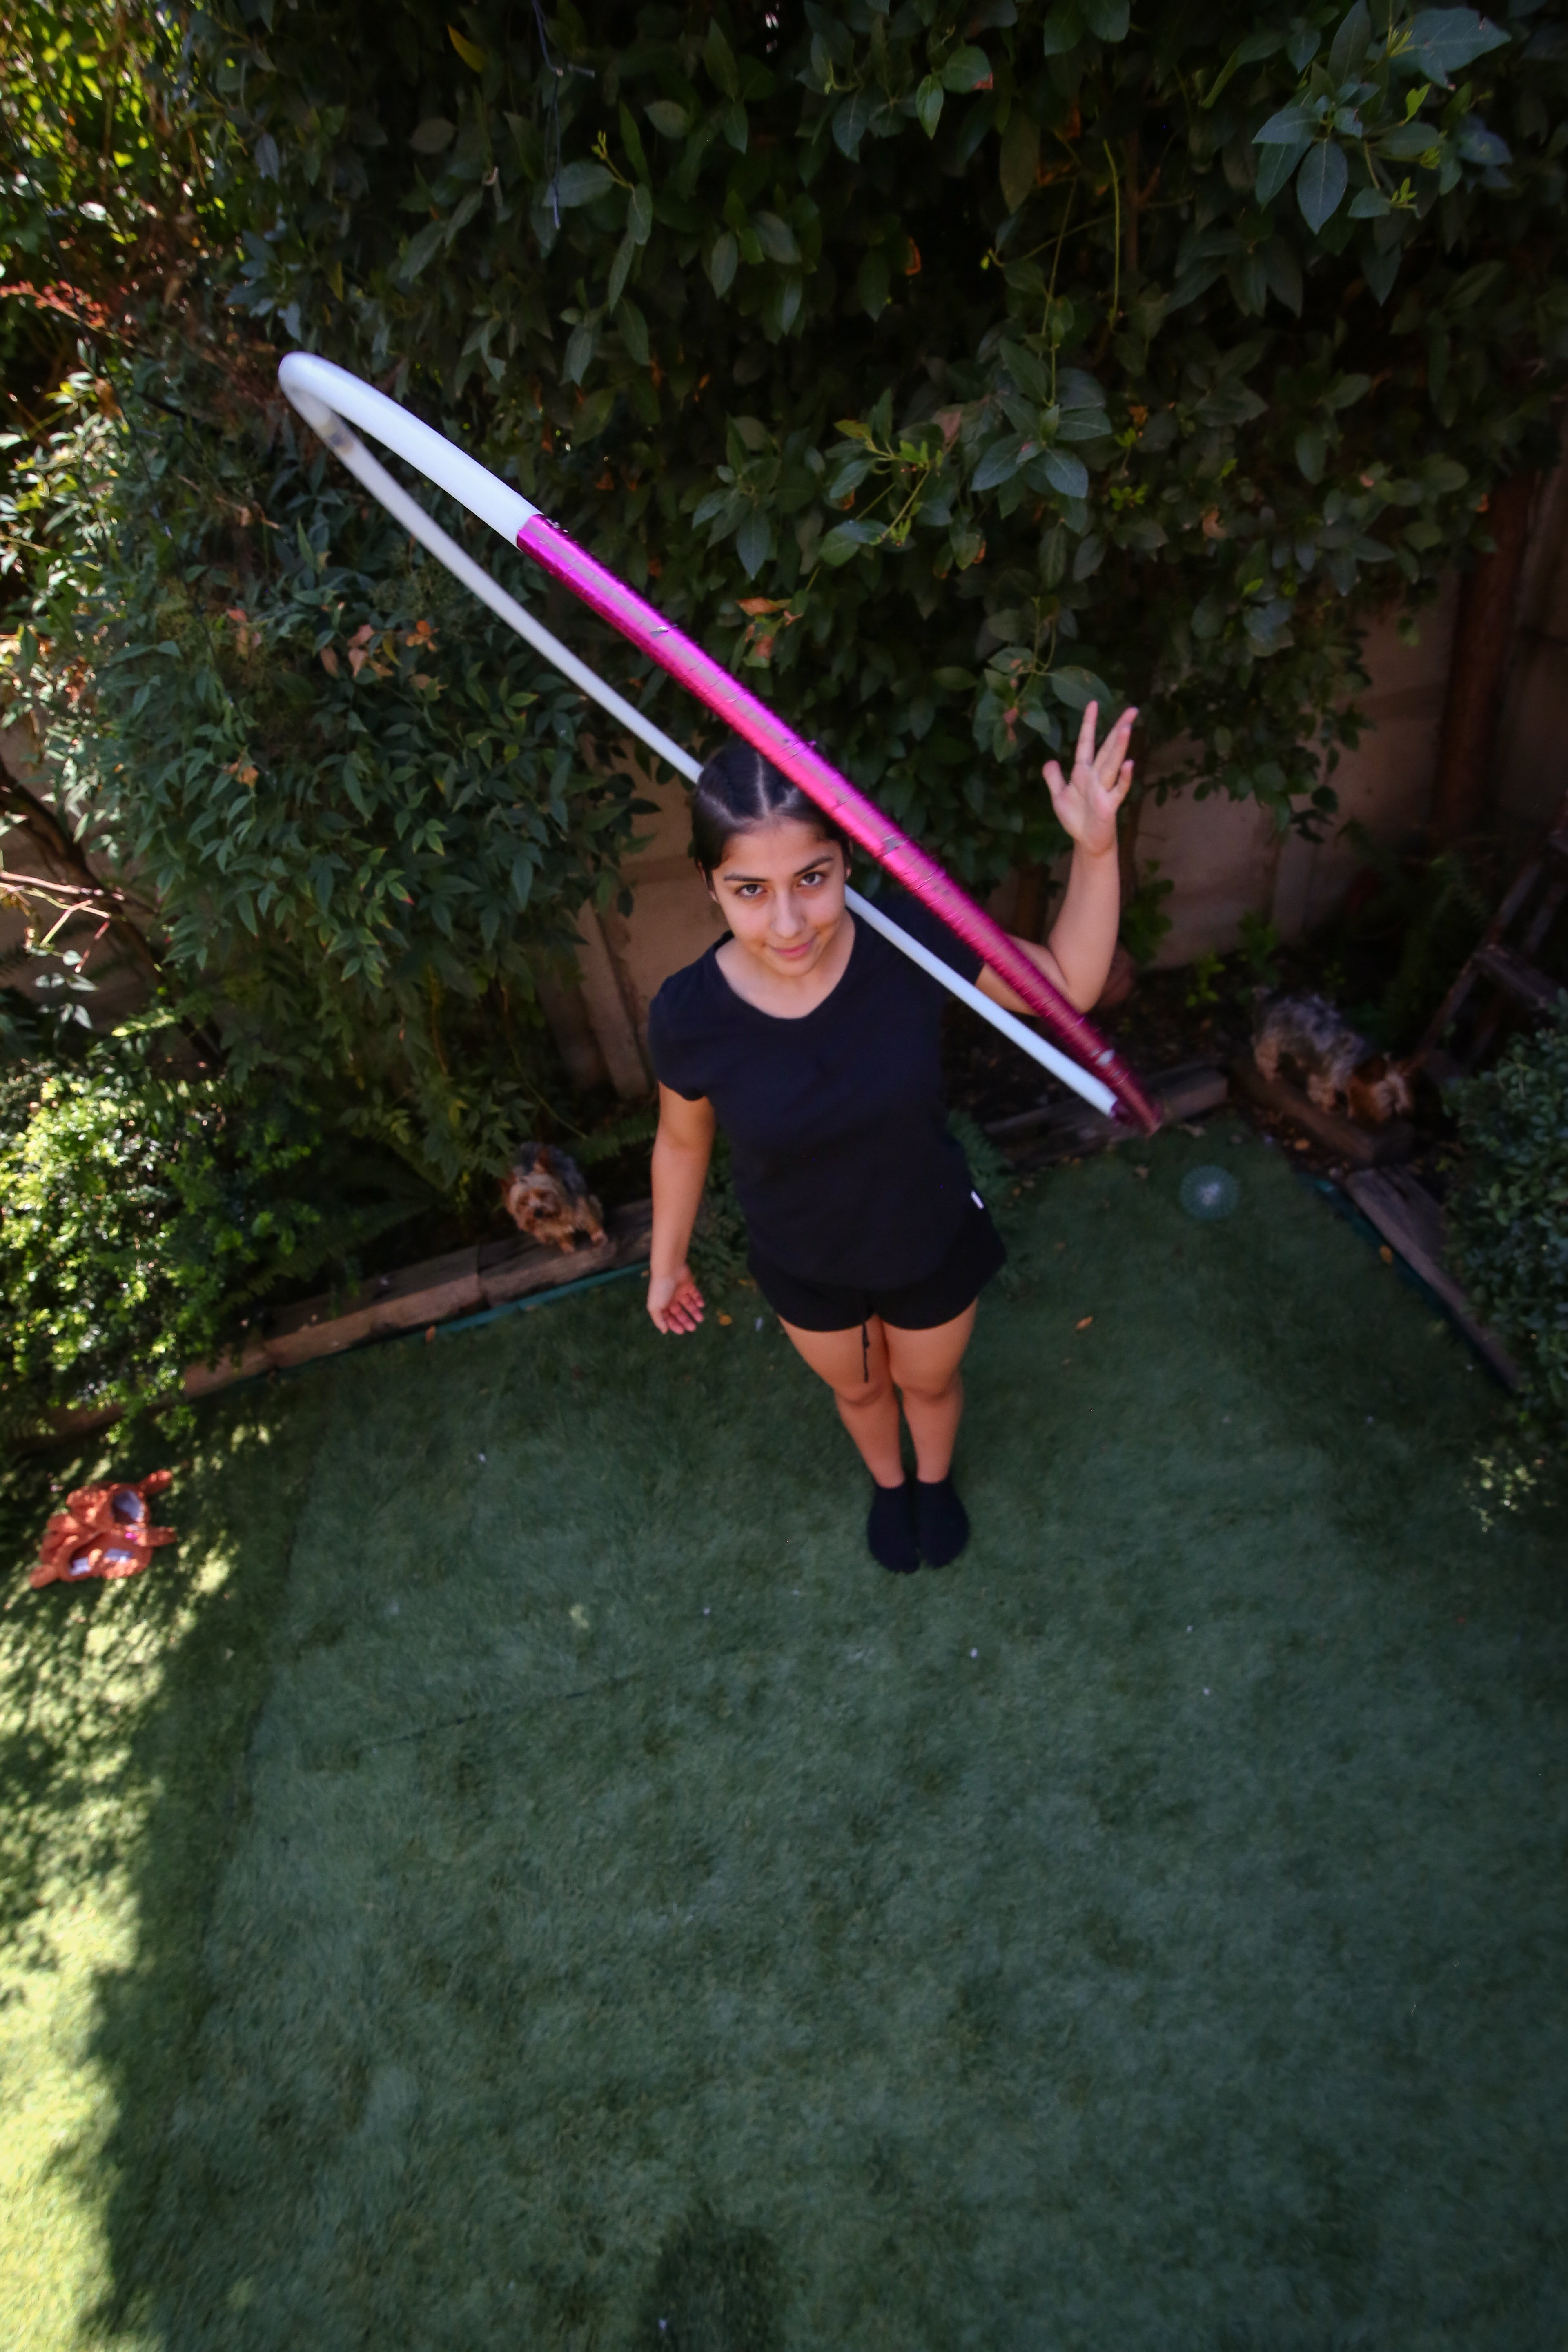
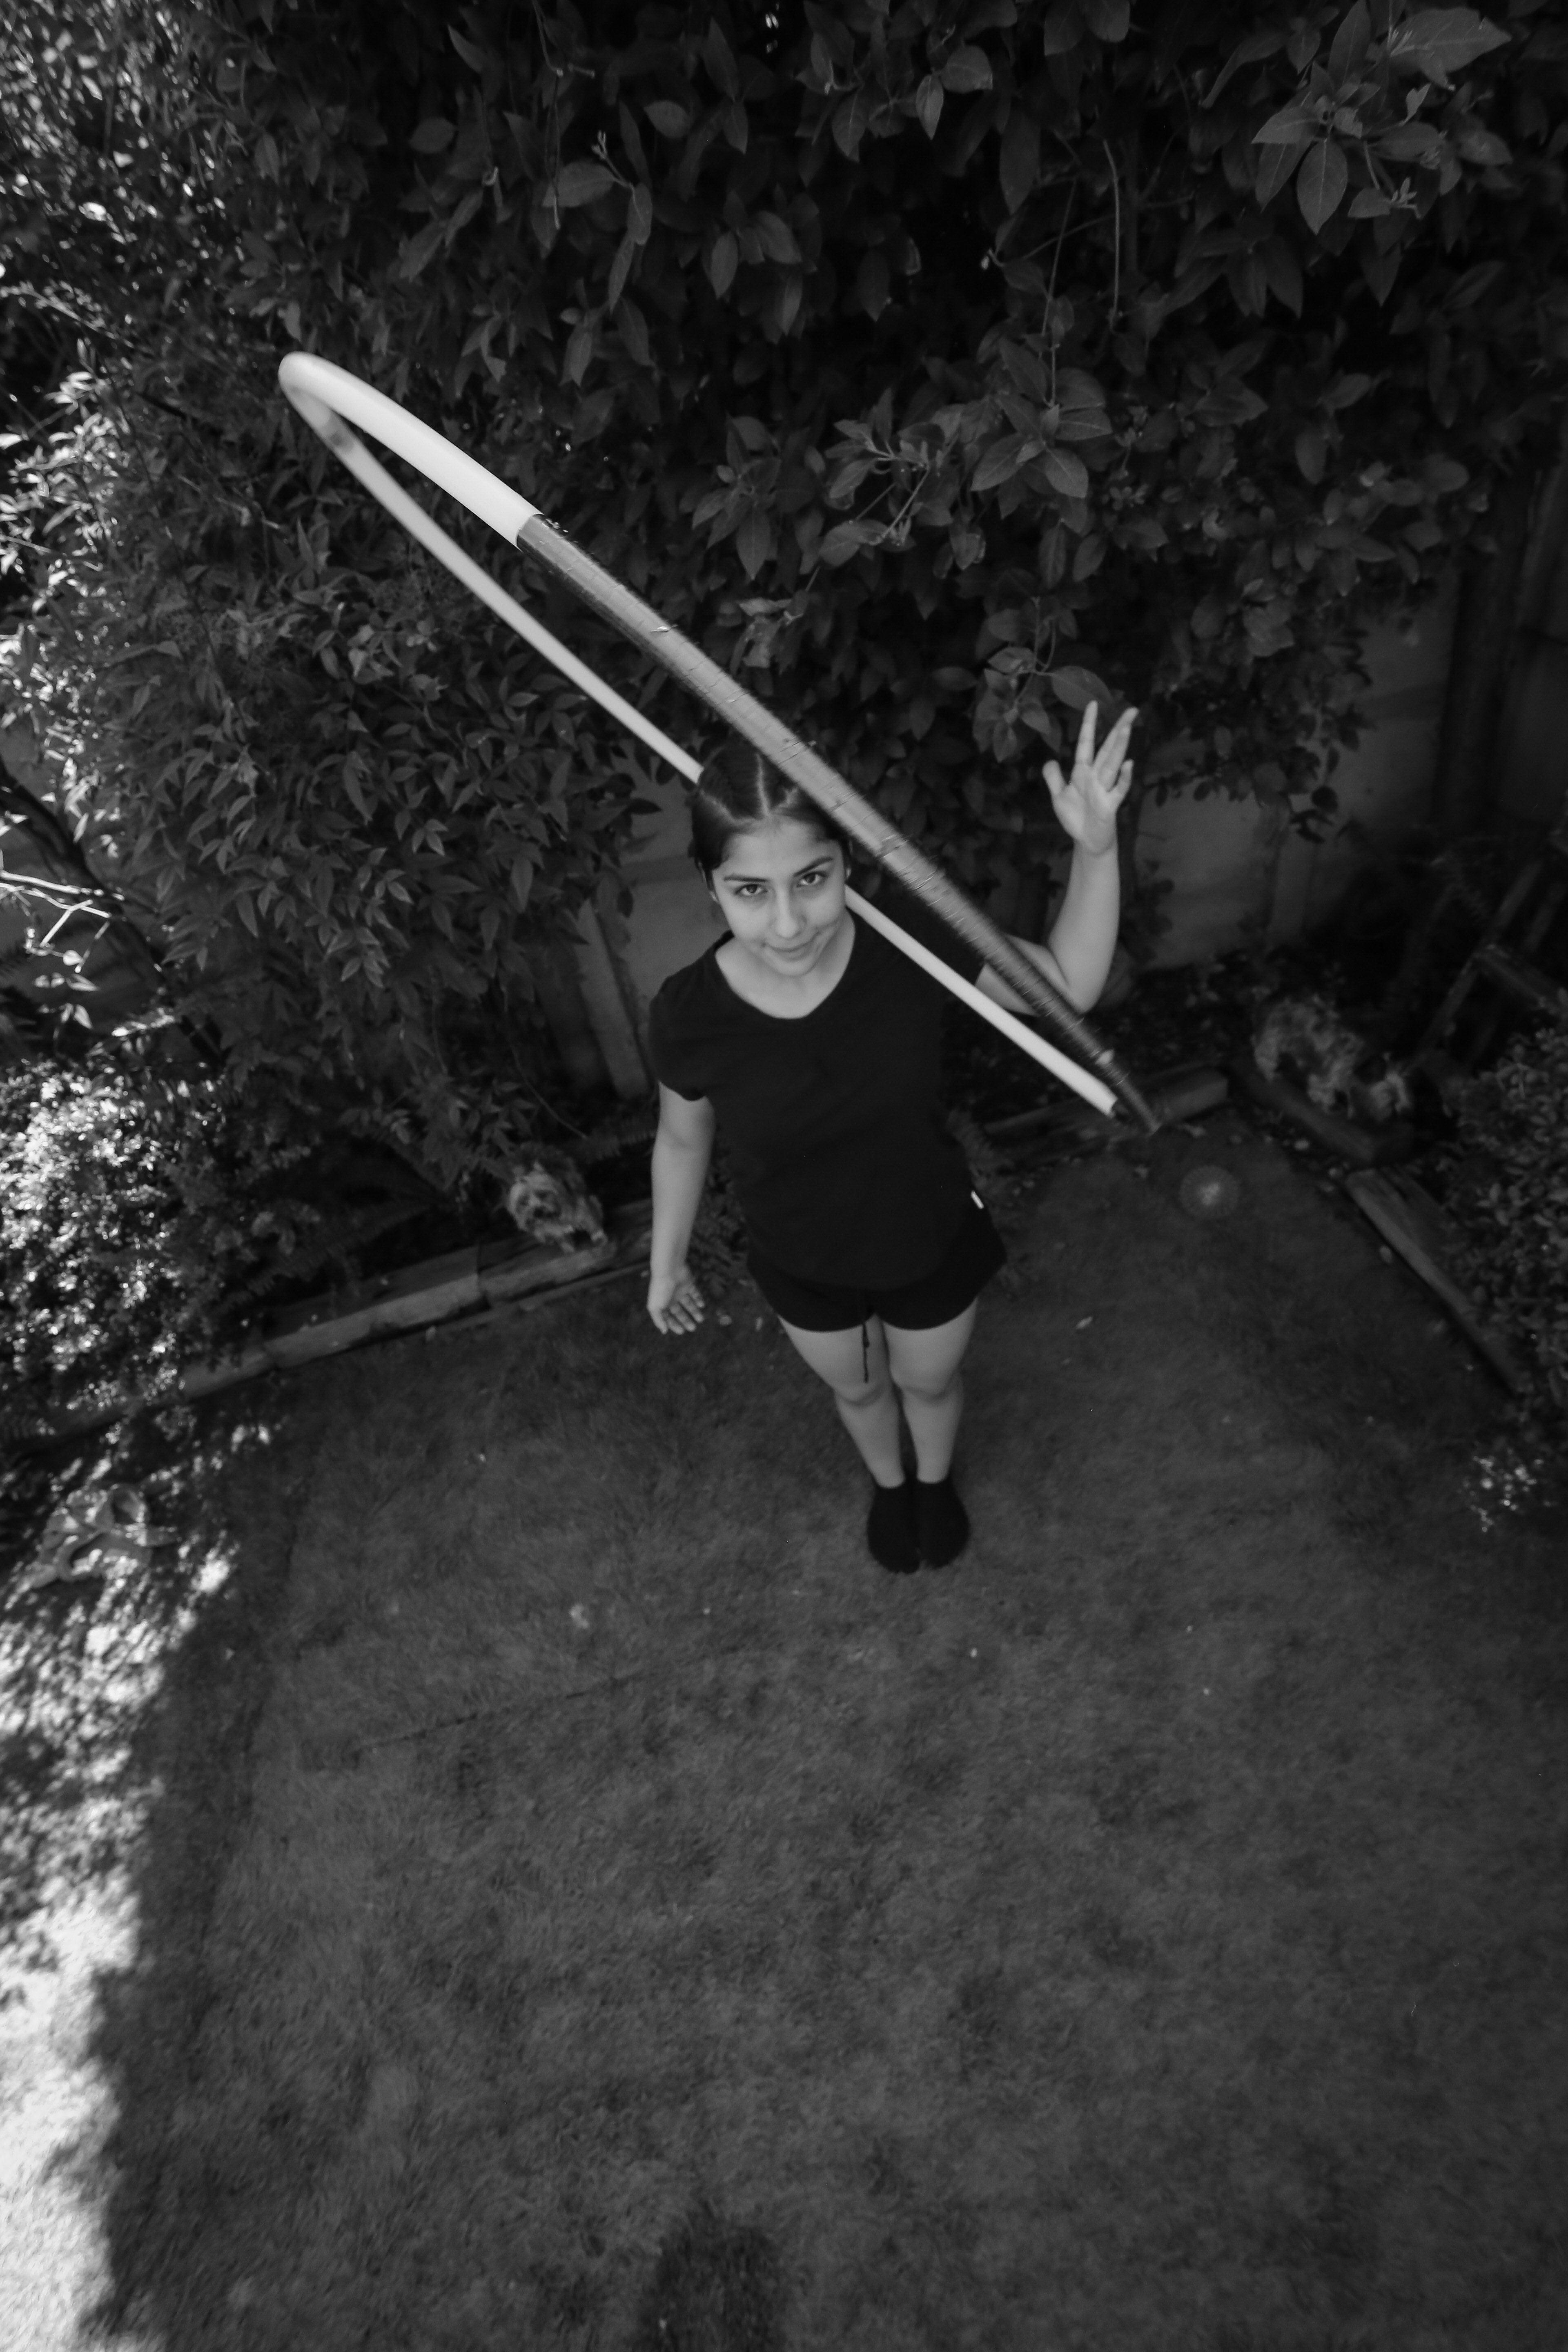
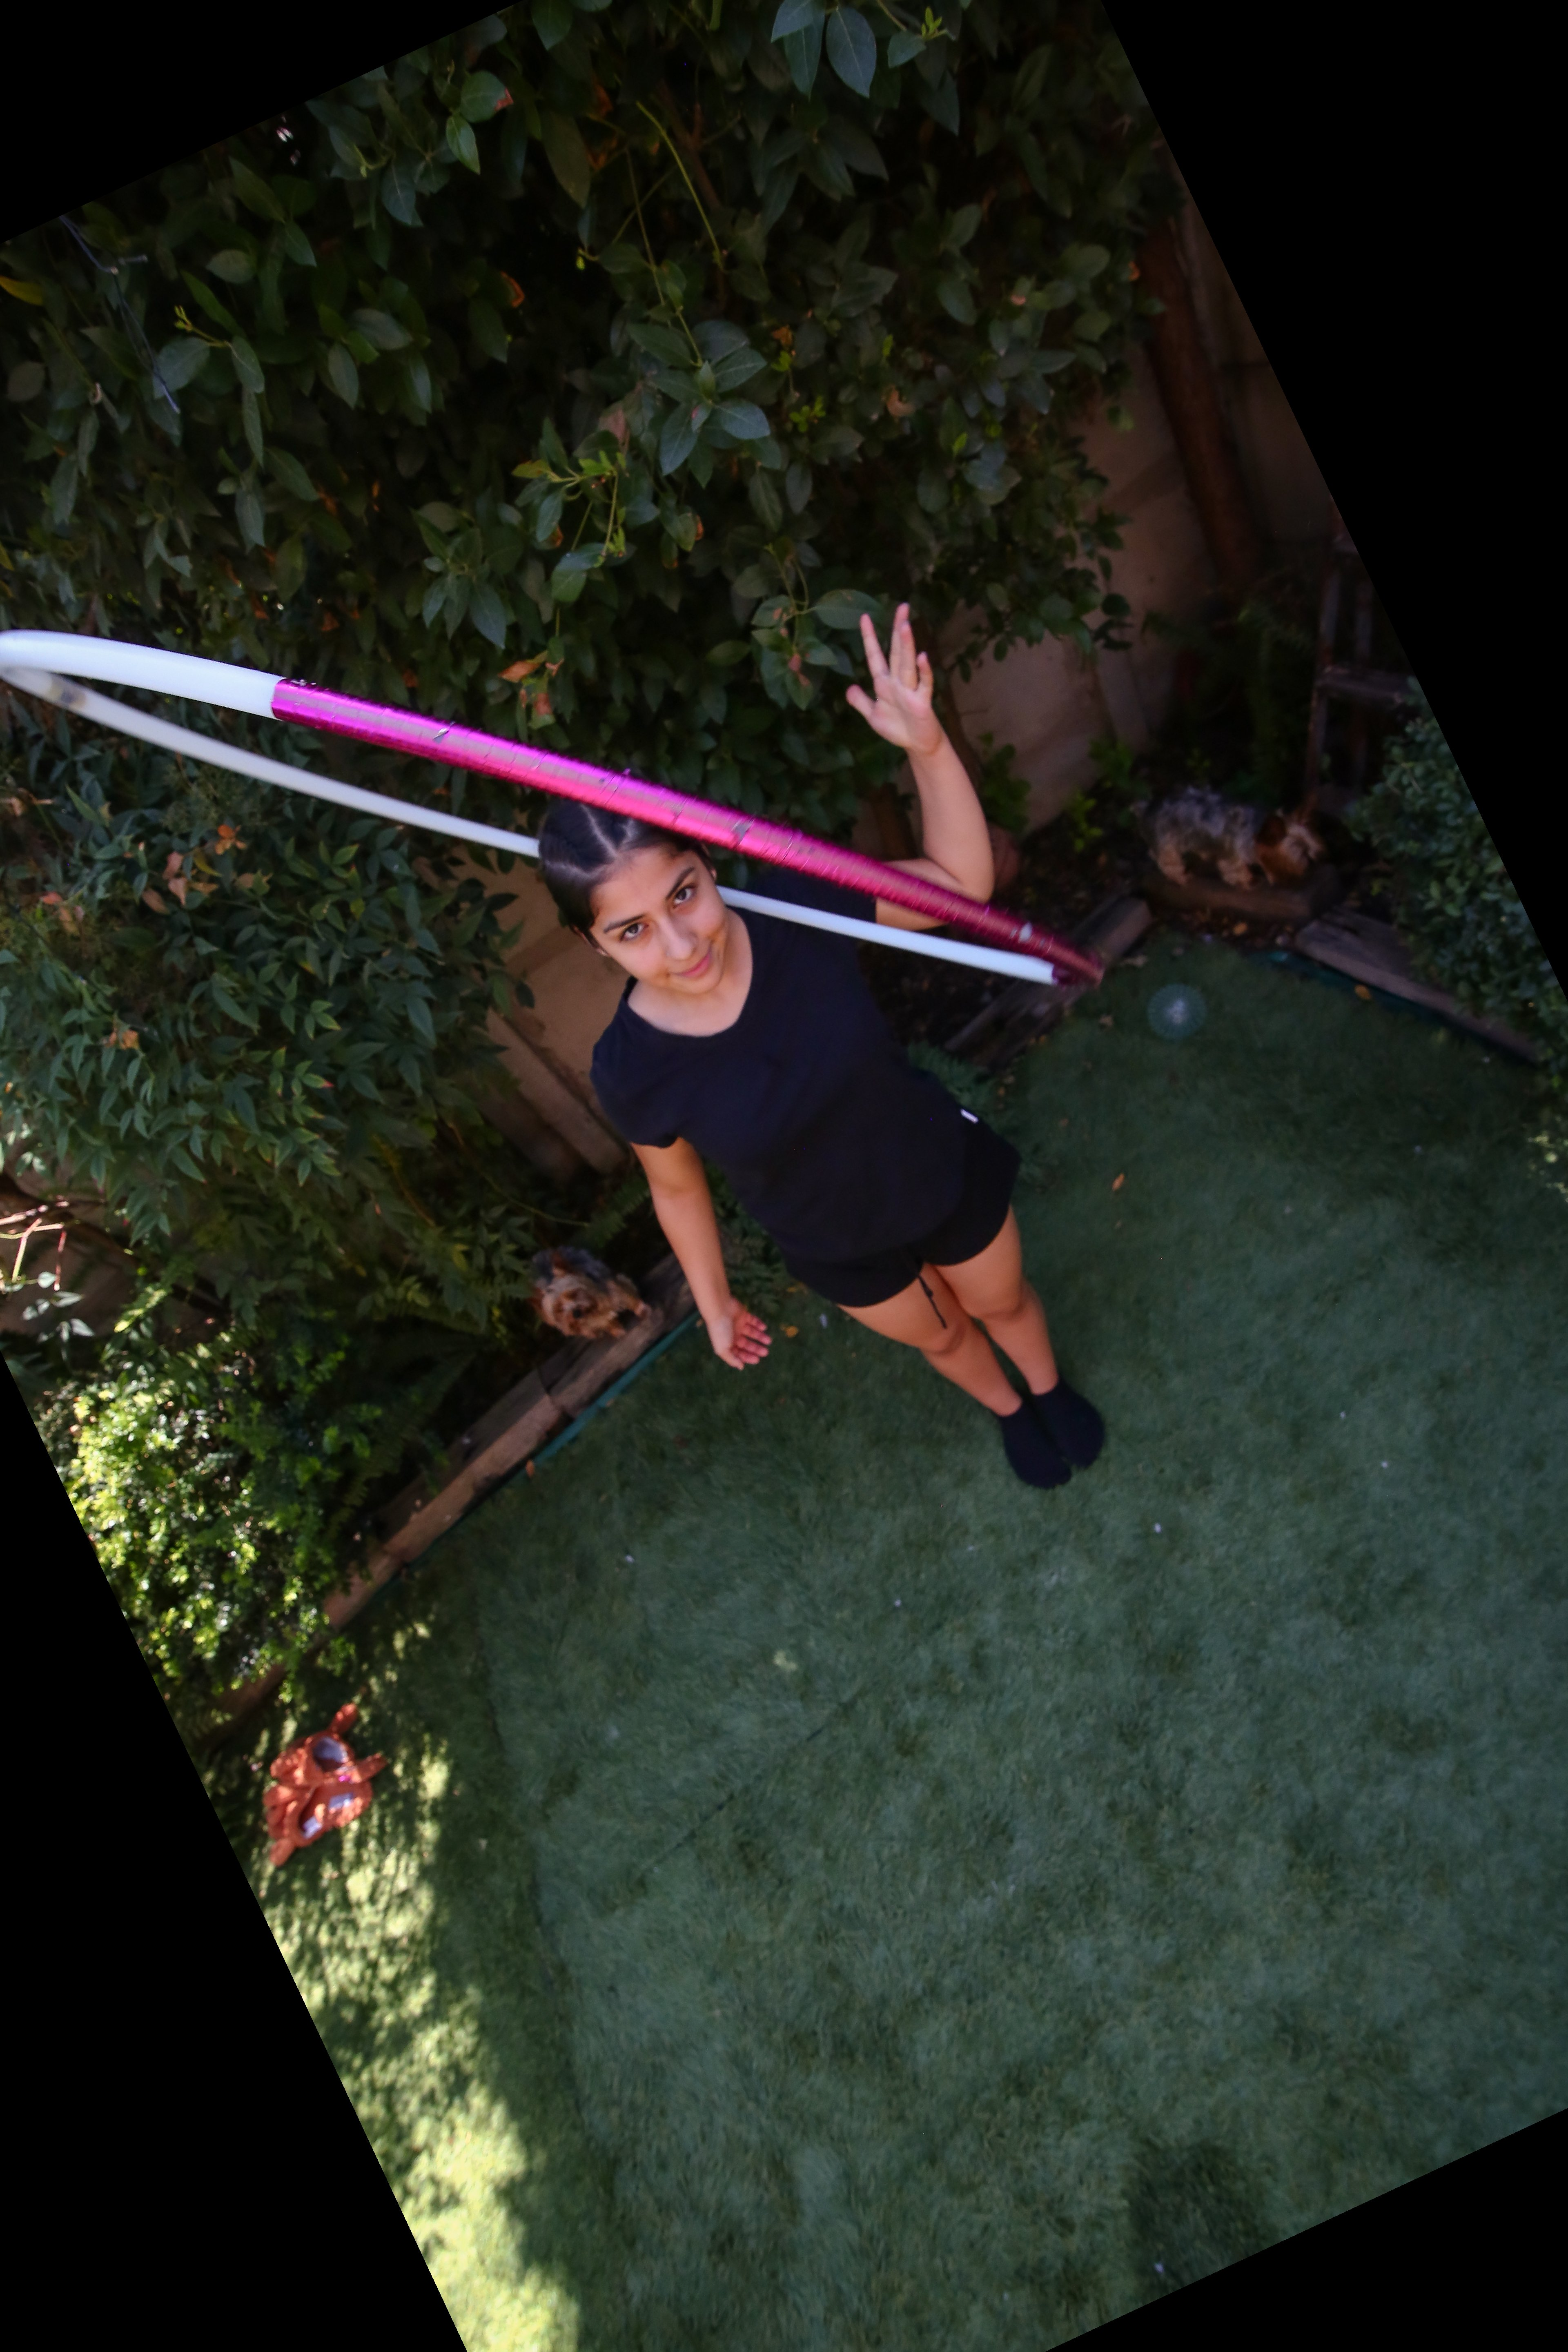
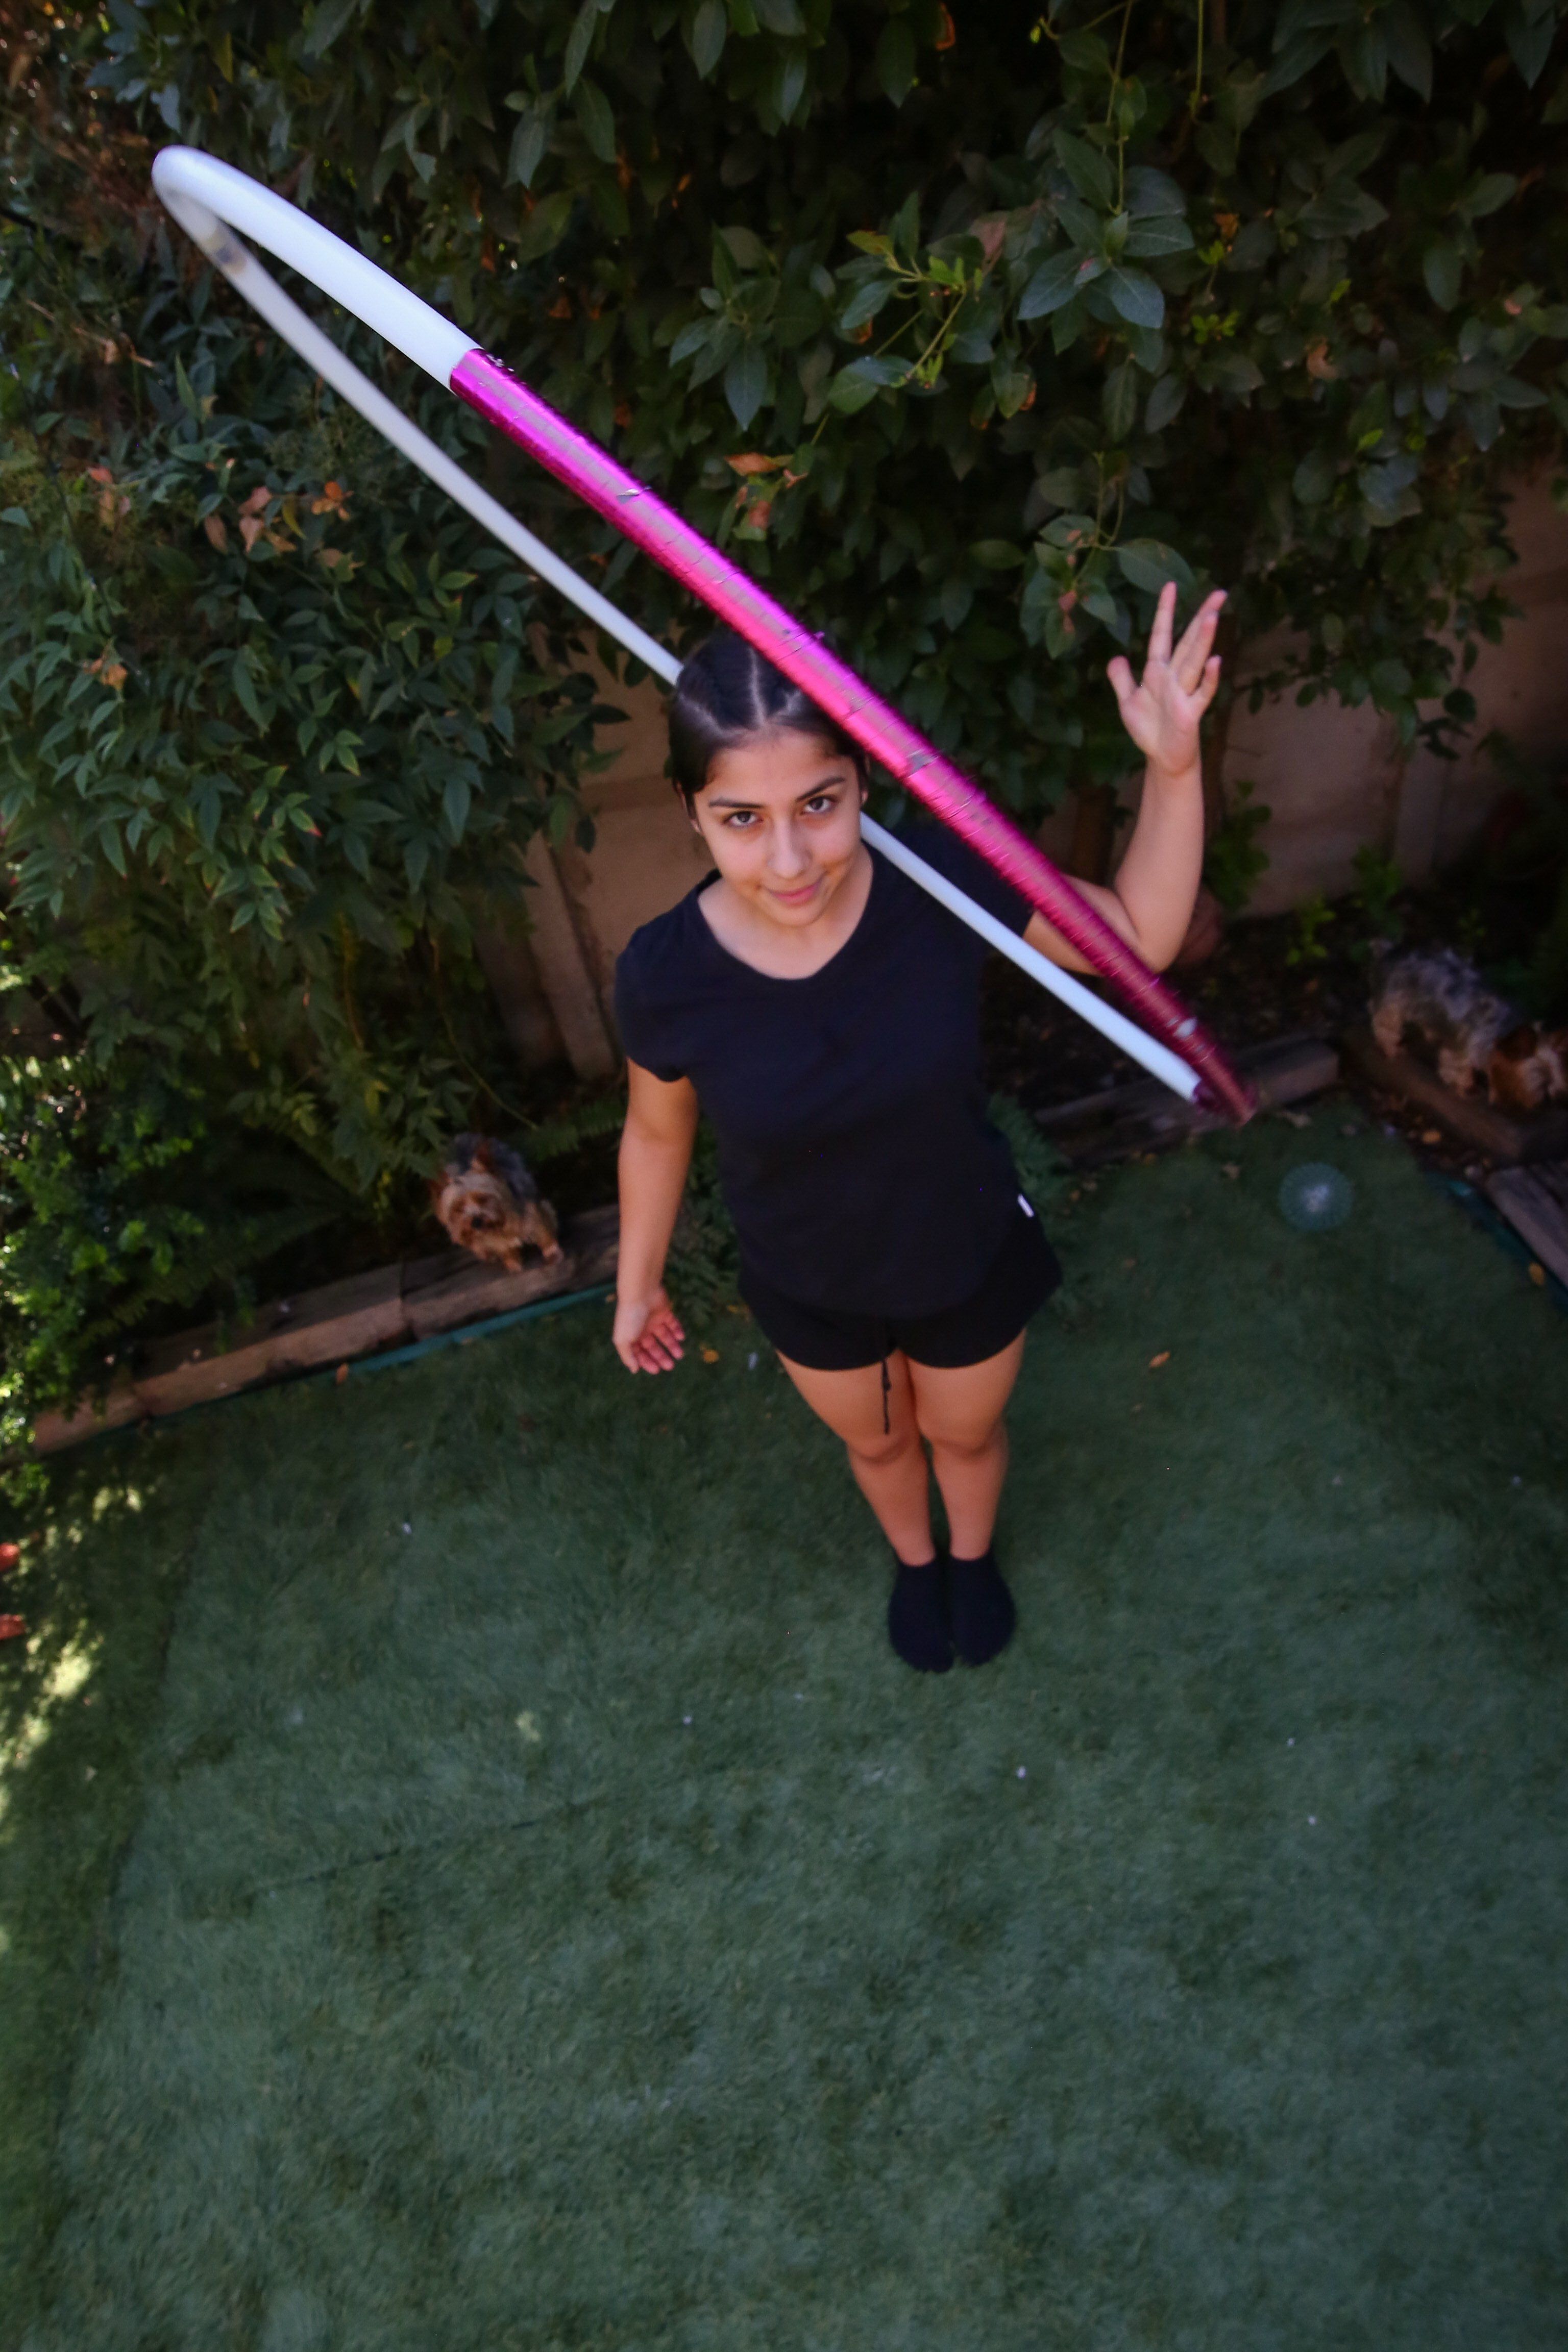


(B) augmentation = grayscale      → original returned at rank 1
(B) augmentation = rotate 25°     → original returned at rank 1
(B) augmentation = crop 80%       → original returned at rank 1

→ Family B has a crisp answer for every augmentation, even though Family A had 0.


In [19]:
# --- Family B: Augmentation-synthetic ---
# Apply two perturbations to the DIGITAL query, see if the original returns at the top.
# Because there's exactly 1 relevant doc per augmented query (the original), this works
# for *every* photo in the library — film, digital, anything. No cohort blind spots.
from PIL import ImageOps

original = load_image(demo_path)
augmentations = {
    "grayscale":   ImageOps.grayscale(original).convert("RGB"),
    "rotate 25°":  original.rotate(25, expand=False),
    "crop 80%":    original.crop((
                       int(original.width  * 0.10), int(original.height * 0.10),
                       int(original.width  * 0.90), int(original.height * 0.90),
                   )),
}

embedder = services.get_embedder()
imgs   = list(augmentations.values())
names  = list(augmentations.keys())
vecs   = embedder.embed(imgs)

# Render original + each augmented version side-by-side so you SEE what's being tested
import io, base64
def _pil_to_data_uri(img: Image.Image) -> str:
    buf = io.BytesIO(); img.convert("RGB").save(buf, format="JPEG", quality=85)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()

def _img_html(img: Image.Image, label: str, border: str = "#ddd") -> str:
    return (
        f'<div style="display:inline-block;margin:4px;text-align:center;font-size:11px;max-width:140px">'
        f'<img src="{_pil_to_data_uri(img)}" style="height:140px;border:2px solid {border}" />'
        f'<div><b>{label}</b></div></div>'
    )

html = ["<h4>Family B: augmentation invariance — DIGITAL query</h4>"]
html.append(_img_html(original, "original", border="#c00"))
html.append("<span style='font-size:30px;color:#999'>&rarr;</span>")
for name, img in augmentations.items():
    html.append(_img_html(img, name))
display(HTML("".join(html)))

print()
for name, vec in zip(names, vecs):
    res = store.search(vec, top_k=10)
    top_hashes = [(r.payload or {}).get("file_hash") for r in res]
    if demo_row["file_hash"] in top_hashes:
        rank = top_hashes.index(demo_row["file_hash"]) + 1
        verdict = f"original returned at rank {rank}"
    else:
        verdict = "original NOT in top-10"
    print(f"(B) augmentation = {name:14s} → {verdict}")

print("\n→ Family B has a crisp answer for every augmentation, even though Family A had 0.")

In [20]:
# --- Family C: Human judgment ---
# Look at the top-10 the system returned for the DIGITAL query (rendered in Part 1)
# and mark each one 1 (relevant) / 0 (not). Order matches the ranks shown there.
#
# Edit the list below by EYE — there is no "right" answer, that's the whole point.
human_judgment_digital = [
    # rank 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
    1, 1, 1, 1, 1, 1, 1, 1, 1, 0,   # <-- placeholder values, replace with your judgments
]
n_c = sum(human_judgment_digital)
print(f"(C) Human says {n_c}/10 of the top-10 are relevant.")
print(f"    Re-run this cell tomorrow with fresh eyes — your number may shift by ±2.")
print(f"    THAT shift is the human-judgment bias. It's small per-query, large in aggregate.")

(C) Human says 9/10 of the top-10 are relevant.
    Re-run this cell tomorrow with fresh eyes — your number may shift by ±2.
    THAT shift is the human-judgment bias. It's small per-query, large in aggregate.


### The triangulation move (the actual lesson)

Look at what just happened on the **digital query**:

- (A) Metadata proxy: `0` relevant docs. The proxy is *blind* to this cohort.
- (B) Augmentation: every augmentation produced a crisp rank for the original. The proxy is *fully covered* — works on any photo.
- (C) Human: whatever you marked above. Maybe `2/10`, maybe `5/10`. *Subjective and small-N* — but those are *real perceived* relevance judgments, the closest thing to ground truth.

Three different signals about the same query. Each biased in a different direction. Now imagine running this for **all 205 photos** instead of one:

- If DINOv3 wins under (A) *and* (B) *and* (C), you're very confident.
- If it wins (B) but loses (A), you've learned something: *the model knows about low-level invariance but isn't grouping mid-level perceptual content the way the rolls are organized*.
- If it wins (A) but loses (C), the rolls are easy and the photos visually inside them are repetitive. The model is over-fitting a cohort signal.

Either way, you've got something to say in the interview that isn't *"the number went up."*

> **Senior-ism**: *a biased eval you understand* beats *a "perfect" eval you can't interpret*. Your job in an interview is to **name your biases out loud before the interviewer asks**. It converts the bias from a gotcha into a demonstration of rigor.

## Part 3 — Eval as a product decision

This is the piece most people miss. **The eval you pick *is* the product spec in disguise.** By choosing `roll_tags` as the relevance label, you are telling LUKI: *the product's job is to return photos from the same roll.* That's a product decision, not a statistics decision.

Alternate product specs produce alternate evals on this exact dataset:

| Product spec | Right relevance label here |
|---|---|
| "Find near-duplicates so I can deduplicate" | Augmentation-synthetic (invariance) |
| "Find photos from the same roll/trip" | `roll_tags` |
| "Find photos that *look* alike regardless of when shot" | Human, or a learned perceptual metric |
| "Find photos with similar shooting conditions" | `camera` + `film_stock` + `iso` |
| "Find photos semantically related (beach, portrait, etc.)" | CLIP-text queries, human-labeled tags |

If an interviewer asks *"why `roll_tags` and not the last one?"*, the senior answer is **not** *"that's what I had data for."* It's:

> *"Because the LUKI user story I'm optimizing is **trip rediscovery** — given a photo, find the rest of the day. `roll_tags` is the closest proxy in this dataset for that story. If the product shifted toward semantic search, I'd swap to CLIP-text eval — and most of the pipeline (ETL, embedding, retrieval) wouldn't change. Eval portability is part of architectural quality."*

---

## Senior-level questions to defend out loud

Close the notebook. Can you answer each in 30 seconds without reading?

1. **"Why can't we just use accuracy?"** — Three independent reasons.
2. **"You used `roll_tags` as the positive label. What's the bias?"** — Name at least two failure modes (cohort coverage + temporal/visual conflation).
3. **"Why is augmentation-invariance circular for DINOv3 and still useful?"** — Sanity-check argument.
4. **"Your library has 19 digital + 186 film photos. How does that affect your reported metric?"** — The cohort-averaging trap.
5. **"When would you push back on being asked for a single headline metric?"** — What conditions make a single number dishonest.
6. **"Your eval set *is* your product spec. Defend that claim."** — Worked example.

If any feel shaky, say which — that's where we'll dig in before moving to `03b`.

---

## What's next

**`03b — ir_metrics.ipynb`**: with the framing in place, we finally pick up the tools — Recall@k, MRR, AP — and watch them compute on the queries you just looked at. Then we productivize `src/luki/eval/metrics.py`.